# 📊 KPI Tracker - the self-serve Monday scorecard

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/phoebefu6/phoebe-the-builder/blob/main/analytics-accelerator/kpi-tracker/demo.ipynb)
[![Binder](https://mybinder.org/badge_logo.svg)](https://mybinder.org/v2/gh/phoebefu6/phoebe-the-builder/main?labpath=analytics-accelerator/kpi-tracker/demo.ipynb)

> **Pain point:** execs ask for the same metrics every Monday, and an analyst rebuilds the same pull by hand each week.

This notebook turns a tidy metric time series + a target config into the exact answer the Monday email needs:

1. **Sample data** - 13 weeks of three business metrics in long format
2. **Score one metric** - latest value, WoW / MoM deltas, trend, RAG vs target
3. **Build the full scorecard** - every metric, one table
4. **Visualize** - a RAG scorecard heat-strip + trend lines
5. **Try your own** - swap in your CSV and targets


## Step 1 - the core scoring logic

Pure pandas, no UI. Long format `[date, metric, value]` in, a structured score per metric out.
`direction` says whether **higher is better** (revenue) or **lower is better** (churn), which flips the RAG comparison.


In [1]:
from __future__ import annotations

from typing import Any, Dict, List, Optional

import numpy as np
import pandas as pd

AMBER_BAND = 0.10  # within 10% of target = amber, beyond = red


def _pct_change(curr: float, prev: Optional[float]) -> Optional[float]:
    if prev is None or prev == 0 or pd.isna(prev):
        return None
    return round(100 * (curr - prev) / abs(prev), 1)


def _value_on_or_before(s: pd.Series, asof: pd.Timestamp) -> Optional[float]:
    window = s[s.index <= asof]
    return None if window.empty else float(window.iloc[-1])


def _rag(value: float, target: float, direction: str) -> str:
    if direction == "down":  # lower is better
        if value <= target:
            return "green"
        return "amber" if value <= target * (1 + AMBER_BAND) else "red"
    if value >= target:
        return "green"
    return "amber" if value >= target * (1 - AMBER_BAND) else "red"


def score_metric(df, metric, target=None, direction="up"):
    sub = df[df["metric"] == metric].copy()
    sub["date"] = pd.to_datetime(sub["date"])
    s = sub.sort_values("date").set_index("date")["value"].astype(float)
    asof = s.index.max()
    latest = float(s.iloc[-1])
    wow = _pct_change(latest, _value_on_or_before(s, asof - pd.Timedelta(days=7)))
    mom = _pct_change(latest, _value_on_or_before(s, asof - pd.Timedelta(days=30)))
    tail = s.tail(8)
    slope = np.polyfit(range(len(tail)), tail.values, 1)[0] if len(tail) >= 2 else 0
    trend = "up" if slope > 0 else "down" if slope < 0 else "flat"
    out = {"metric": metric, "asof": asof.date().isoformat(), "latest": round(latest, 2),
           "wow_pct": wow, "mom_pct": mom, "trend": trend, "direction": direction, "target": target}
    if target is not None:
        out["target_pct"] = round(100 * latest / target, 1) if target else None
        out["rag"] = _rag(latest, target, direction)
    else:
        out["rag"] = "none"
    return out


def build_scorecard(df, targets):
    return [score_metric(df, m, c.get("target"), c.get("direction", "up"))
            for m, c in targets.items()]

print("core logic loaded")

core logic loaded


## Step 2 - sample data

13 weeks of **Revenue**, **New signups**, and **Churn %** in long format - the shape any BI export can produce.

In [2]:
rng = np.random.default_rng(7)
weeks = pd.date_range("2026-03-30", periods=13, freq="W-MON")
rows, revenue, signups, churn = [], 120_000.0, 800.0, 4.5
for d in weeks:
    revenue *= 1 + rng.normal(0.02, 0.03)
    signups *= 1 + rng.normal(0.015, 0.05)
    churn += rng.normal(-0.05, 0.2)
    rows += [
        {"date": d, "metric": "Revenue ($)", "value": round(revenue, 0)},
        {"date": d, "metric": "New signups", "value": round(signups, 0)},
        {"date": d, "metric": "Churn (%)", "value": round(max(churn, 0.5), 2)},
    ]
df = pd.DataFrame(rows)
df.tail(6)

,date,metric,value
33,2026-06-15,Revenue ($),128938.00
34,2026-06-15,New signups,823.00
35,2026-06-15,Churn (%),2.37
36,2026-06-22,Revenue ($),131391.00
37,2026-06-22,New signups,872.00
38,2026-06-22,Churn (%),2.20


## Step 3 - build the scorecard

Set a target and a direction per metric, then score them all in one call.

In [3]:
targets = {
    "Revenue ($)": {"target": 160_000.0, "direction": "up"},
    "New signups": {"target": 1000.0, "direction": "up"},
    "Churn (%)":   {"target": 3.0, "direction": "down"},  # lower is better
}
score = pd.DataFrame(build_scorecard(df, targets))
score[["metric", "latest", "target", "target_pct", "wow_pct", "mom_pct", "trend", "rag"]]

,metric,latest,target,target_pct,wow_pct,mom_pct,trend,rag
0,Revenue ($),131391.0,160000.0,82.1,1.9,1.7,up,red
1,New signups,872.0,1000.0,87.2,6.0,14.1,up,red
2,Churn (%),2.2,3.0,73.3,-7.2,-35.5,down,green


## Step 4 - visualize

Two views an exec reads in five seconds: a **RAG status strip** (are we green?) and the **trend lines** vs target.

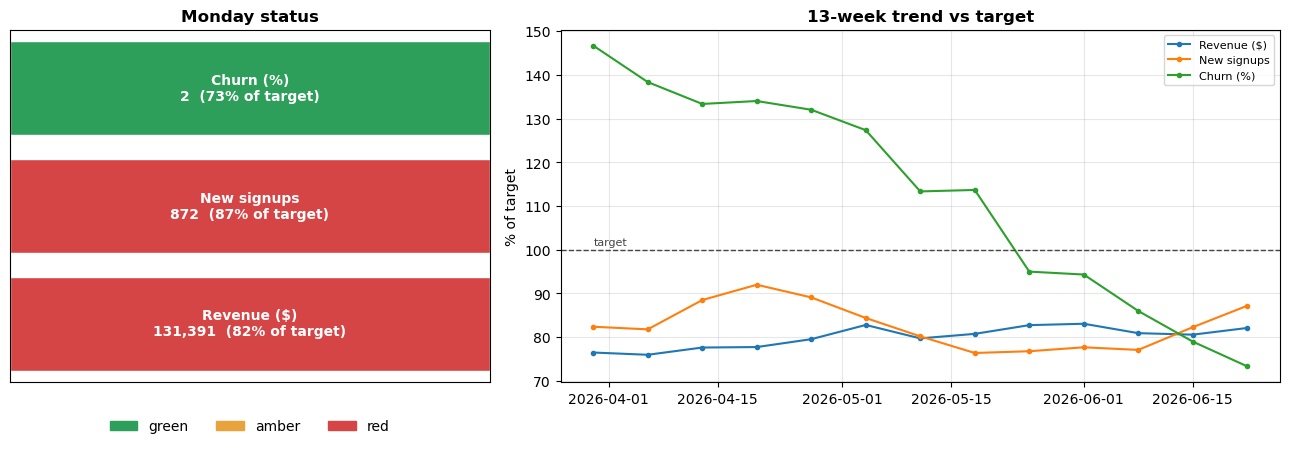

In [4]:
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

RAG = {"green": "#2e9e5b", "amber": "#e8a33d", "red": "#d64545", "none": "#9aa0a6"}
fig, axes = plt.subplots(1, 2, figsize=(13, 4.6), gridspec_kw={"width_ratios": [1, 1.5]})

# Left: RAG status strip
sc = build_scorecard(df, targets)
ax = axes[0]
for i, r in enumerate(sc):
    ax.barh(i, 1, color=RAG[r["rag"]], edgecolor="white")
    ax.text(0.5, i, f"{r['metric']}\n{r['latest']:,.0f}  ({r['target_pct']:.0f}% of target)",
            ha="center", va="center", color="white", fontsize=10, fontweight="bold")
ax.set_xlim(0, 1); ax.set_ylim(-0.5, len(sc) - 0.5)
ax.set_xticks([]); ax.set_yticks([]); ax.set_title("Monday status", fontweight="bold")
ax.legend(handles=[Patch(color=RAG[k], label=k) for k in ["green", "amber", "red"]],
          loc="lower center", ncol=3, frameon=False, bbox_to_anchor=(0.5, -0.18))

# Right: trend lines vs target
ax = axes[1]
for m, cfg in targets.items():
    s = df[df["metric"] == m].set_index("date")["value"]
    norm = s / cfg["target"] * 100  # index to % of target so all fit one axis
    ax.plot(s.index, norm, marker="o", ms=3, label=m)
ax.axhline(100, ls="--", color="#444", lw=1)
ax.text(df["date"].min(), 101, "target", fontsize=8, color="#444")
ax.set_ylabel("% of target"); ax.set_title("13-week trend vs target", fontweight="bold")
ax.legend(fontsize=8); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("kpi.png", dpi=144, bbox_inches="tight")
plt.show()

## Summary

| Metric | Latest | % of target | RAG |
|---|---|---|---|
The table and chart above are the entire Monday email - generated, not hand-built. The scoring core (`kpi.py`) is UI-free, so it drops straight into the platform shell as a **KPI Tracker** app or runs in a scheduled report job.

In [5]:
summary = pd.Series([r["rag"] for r in sc]).value_counts().to_dict()
print("RAG summary:", summary)
print("\nThe one-line exec read:")
g, a, rd = summary.get("green", 0), summary.get("amber", 0), summary.get("red", 0)
print(f"  {g} on target | {a} at risk | {rd} off target")

RAG summary: {'red': 2, 'green': 1}

The one-line exec read:
  1 on target | 0 at risk | 2 off target


## 🔧 Try your own

Point this at a real export. Required columns: **date**, **metric**, **value** (long format).

In [6]:
# my_df = pd.read_csv("your_metrics.csv")           # columns: date, metric, value
# my_targets = {
#     "MRR": {"target": 50_000, "direction": "up"},
#     "Support backlog": {"target": 20, "direction": "down"},
# }
# pd.DataFrame(build_scorecard(my_df, my_targets))

---
**Part of [phoebe-the-builder](https://github.com/phoebefu6/phoebe-the-builder)** - Day 22 of the 60-project FDE portfolio.

Run the interactive Streamlit version:
```bash
pip install -r requirements.txt
streamlit run app.py
```